In [1]:
%cd /run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough

import argparse, inspect, json, os, pickle, socket, subprocess, warnings, random, math, librosa, shutil
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchaudio
import lightning as L
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers.tensorboard import TensorBoardLogger
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

from functools import reduce
import umap
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import commons, models, utils, losses, lightning_wrapper
from cough_datasets import CoughDatasets, CoughDatasetsCollate, CoughDiseaseBinaryBatchSampler

torch.set_float32_matmul_precision("medium")
cmap = cm.get_cmap("viridis")

/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough


ImportError: attempted relative import beyond top-level package

In [ ]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/longitudinal_original.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

In [ ]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/coda/solicited_original.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

In [ ]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_solicited.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

In [ ]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/DatabaseLLM/TBscreen_Dataset/metadata_longitudinal.csv')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

In [ ]:
# DB Profile
df_longi = pd.read_csv('/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/cirdz.csv.test')

file_count_per_participant = (
    df_longi
    .groupby("participant")
    .size()
    .reset_index(name="file_count")
)

file_count_stats = file_count_per_participant["file_count"].agg(
    min_count="min",
    mean_count="mean",
    max_count="max"
)

file_count_stats

In [ ]:
df_test = pd.read_csv(f'/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/data/cirdz.csv.test')

## Check Training Result

### Optuna Result

In [2]:
import optuna
import pickle
from plotly.io import show

In [6]:
with open("/run/media/fourier/Data1/Pras/Thesis_Nexus/NXSCough/logs_search/search_bilstm_mfcc/optuna_best.pkl", "rb") as f:
    data_study = pickle.load(f)

In [7]:
study = data_study['study']

In [8]:
data_study

{'params': {'hidden_dim_classifier': 16,
  'dropout': 0.24137277045974667,
  'hidden_size': 256,
  'lstmnum_layers': 4,
  'filter_length': 2048,
  'win_length': 1024,
  'hop_length': 32,
  'n_mel_channels': 13,
  'mel_fmin': 120,
  'mel_fmax': 8000},
 'score': 0.7056723639052038,
 'study': <optuna.study.study.Study at 0x7f77d8d94c50>}

In [5]:
study.best_trial.params

{'hidden_dim_classifier': 64,
 'dropout': 0.593431639486572,
 'resnet_type': 'resnet18',
 'num_layers_resnet': 1,
 'filter_length': 2048,
 'win_length': 512,
 'hop_length': 64,
 'n_mel_channels': 40,
 'mel_fmin': 500,
 'mel_fmax': 5000}

In [4]:
best_params = study.best_trial.params
print("Best parameters:", best_params)

# To get just the list of parameter names (keys)
param_names = list(best_params.keys())
print("Parameter names:", param_names)

Best parameters: {'hidden_dim_classifier': 192, 'dropout': 0.838331741152155, 'hidden_size': 512, 'lstmnum_layers': 1, 'filter_length': 1024, 'win_length': 512, 'hop_length': 64, 'n_mel_channels': 80, 'mel_fmin': 20, 'mel_fmax': 7000}
Parameter names: ['hidden_dim_classifier', 'dropout', 'hidden_size', 'lstmnum_layers', 'filter_length', 'win_length', 'hop_length', 'n_mel_channels', 'mel_fmin', 'mel_fmax']


In [7]:
fig = optuna.visualization.plot_slice(study, params=param_names)
show(fig)

In [8]:
fig = optuna.visualization.plot_optimization_history(study)
show(fig)

In [12]:
fig = optuna.visualization.plot_param_importances(study)
show(fig)

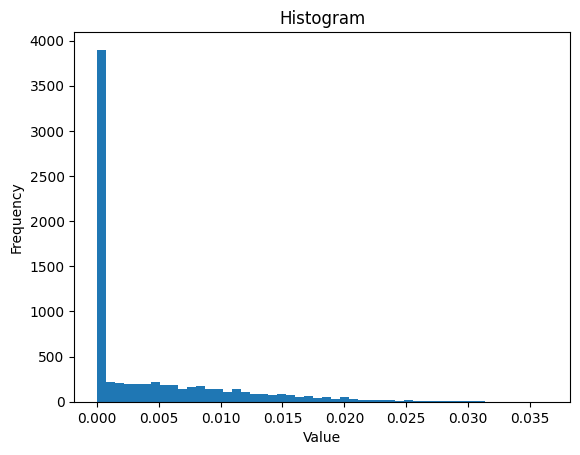

In [12]:
import matplotlib.pyplot as plt

plt.hist(data['additional_array'][0], bins=50)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()